# 注意力机制

## 注意力提示

### 查询、键和值

<div align="center">
    <img src="../img/注意力汇聚.png">
<div>

### 注意力的可视化

In [26]:
import torch
from d2l import torch as d2l

In [27]:
# matrices的形状是(要显示的行数，要显示的列数，查询的数目，键的数目)
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                    cmap='Reds'):
    """显示矩阵热图"""
    d2l.use_svg_display()
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                    sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6)

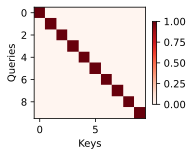

In [28]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

## 注意力汇聚：Nadaraya-Watson核回归

In [29]:
import torch
from torch import nn
from d2l import torch as d2l

### 生成数据集

根据下面的非线性函数生成一个人工数据集，其中加入的噪声项为 $\epsilon$：

$$
y_i = 2\sin(x_i) + x_i^{0.8} + \epsilon,
\tag{10.2.1}
$$

其中 $\epsilon$ 服从均值为 0 和标准差为 0.5 的正态分布。在这里生成了 50 个训练样本和 50 个测试样本。为了更好地可视化之后的注意力模式，需要将训练样本进行排序。

In [30]:
n_train = 50 # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5) # 排序后的训练样本

In [31]:
def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,)) # 训练样本的输出
x_test = torch.arange(0, 5, 0.1) # 测试样本
y_truth= f(x_test)
n_test = len(x_test) # 测试样本数
n_test

50

In [32]:
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
                xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5)

### 平均汇聚

先使用最简单的估计器来解决回归问题。基于平均汇聚来计算所有训练样本输出值的平均值：

$$
f(x) = \frac{1}{n}\sum_{i=1}^{n} y_i,
$$

如下图所示，这个估计器确实不够聪明。真实函数 $f$（“Truth”）和预测函数（“Pred”）相差很大。

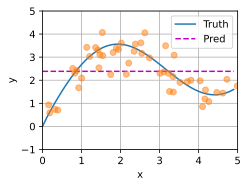

In [33]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

### 非参数注意力汇聚

### 非参数注意力汇聚（Nadaraya–Watson）小结

平均汇聚忽略了输入 $x_i$。Nadaraya–Watson 核回归按输入位置对输出 $y_i$ 加权：

$$
f(x) = \sum_{i=1}^{n} \frac{K(x - x_i)}{\sum_{j=1}^{n} K(x - x_j)} y_i,
$$

其中 $K$ 是核函数。从注意力框架可改写成更一般的**注意力汇聚**：

$$
f(x) = \sum_{i=1}^{n} \alpha(x, x_i) y_i,
$$

- 查询：$x$
- 键值对：$(x_i, y_i)$
- 注意力权重：$\alpha(x, x_i)$（非负且对 $i$ 求和为 1，是有效概率分布）

取高斯核：

$$
K(u) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{u^2}{2}\right).
$$

代入后得到：

$$
\begin{aligned}
f(x)
&= \sum_{i=1}^{n} \alpha(x, x_i) y_i \\
&= \sum_{i=1}^{n}
\frac{\exp\left(-\frac{1}{2}(x - x_i)^2\right)}
{\sum_{j=1}^{n} \exp\left(-\frac{1}{2}(x - x_j)^2\right)}
y_i \\
&= \sum_{i=1}^{n}
\mathrm{softmax}\left(-\frac{1}{2}(x - x_i)^2\right) y_i.
\end{aligned}
$$

**直觉**：$x_i$ 越接近查询 $x$，对应 $y_i$ 的权重越大（更受关注）。

**性质**：权重由距离直接算出、无需训练参数，因此是**非参数注意力汇聚**；预测通常比简单平均更平滑、更接近真实曲线。

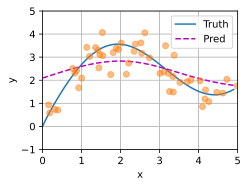

In [34]:
# X_repeat的形状:(n_test, n_train),
# 每一行都包含这相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# X_train包含着键。attention_weights的形状：(n_test, n_train),
# 每一行都包含这要在给定的每个查询的值(y_train)之间分配的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

现在来观察注意⼒的权重。这⾥测试数据的输⼊相当于查询，⽽训练数据的输⼊相当于键。因为两个输⼊都
是经过排序的，因此由观察可知“查询-键”对越接近，注意⼒汇聚的注意⼒权重就越⾼。

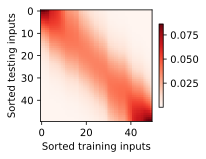

In [35]:
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                    xlabel='Sorted training inputs',
                    ylabel='Sorted testing inputs')

### 带参数注意力汇聚

例如，与 (10.2.6) 略有不同，在下面的查询 $x$ 和键 $x_i$ 之间的距离乘以可学习参数 $w$：

$$
\begin{aligned}
f(x)
&= \sum_{i=1}^{n} \alpha(x, x_i) y_i \\
&= \sum_{i=1}^{n}
\frac{\exp\left(-\frac{1}{2}((x - x_i)w)^2\right)}
{\sum_{j=1}^{n} \exp\left(-\frac{1}{2}((x - x_j)w)^2\right)}
y_i \\
&= \sum_{i=1}^{n}
\mathrm{softmax}\left(-\frac{1}{2}((x - x_i)w)^2\right) y_i.
\end{aligned}
$$

本节的余下部分将通过训练这个模型来学习注意力汇聚的参数。

#### 批量矩阵乘法

In [36]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

In [37]:
# 在注意⼒机制的背景中，我们可以使⽤⼩批量矩阵乘法来计算⼩批量数据中的加权平均值。
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

#### 定义模型

In [38]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数， "键-值"对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape(-1, keys.shape[1])
        self.attention_weights = nn.functional.softmax(-((queries - keys)*self.w)**2 / 2)
        # values的形状为(查询个数，“键-值”对个数)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                            values.unsqueeze(-1)).reshape(-1)

#### 训练

接下来，将训练数据集变换为键和值⽤于训练注意⼒模型。在带参数的注意⼒汇聚模型中，任何⼀个训练样本的输⼊都会和除⾃⼰以外的所有训练样本的“键－值”对进⾏计算，从⽽得到其对应的预测输出。

In [39]:
# X_tile的形状：(n_train, n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状：(n_train, n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))
# keys的形状：('n_train', 'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1- torch.eye(n_train)).type(torch.bool)].reshape((n_train,-1))

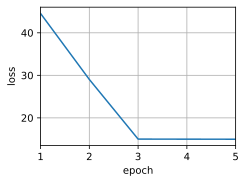

In [40]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))

如下所⽰，训练完带参数的注意⼒汇聚模型后可以发现：在尝试拟合带噪声的训练数据时，预测结果绘制的线不如之前⾮参数模型的平滑。

C:\Users\k\AppData\Local\Temp\ipykernel_25204\502936690.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  self.attention_weights = nn.functional.softmax(-((queries - keys)*self.w)**2 / 2)


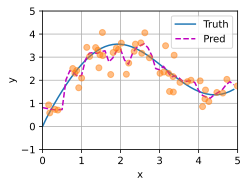

In [41]:
# keys的形状：(n_test, n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1))
# value的形状：(n_test, n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

为什么新的模型更不平滑了呢？下⾯看⼀下输出结果的绘制图：与⾮参数的注意⼒汇聚模型相⽐，带参数的模型加⼊可学习的参数后，曲线在注意⼒权重较⼤的区域变得更不平滑。

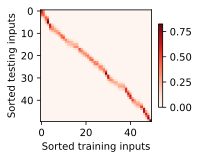

In [42]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
xlabel='Sorted training inputs',
ylabel='Sorted testing inputs')

## 注意力评分函数

从宏观来看，上述算法可以用来实现图10.1.3中的注意力机制框架。图10.3.1说明了如何将注意力汇聚的输出计算成为值的加权和，其中 $a$ 表示注意力评分函数。由于注意力权重是概率分布，因此加权和本质上是加权平均值。

<div align="center">
    <img src="../img/计算注意力汇聚的输出值为加权和.png">
<div>

假设有一个查询 $\mathbf{q} \in \mathbb{R}^q$ 和 $m$ 个“键－值”对 $(\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)$，其中 $\mathbf{k}_i \in \mathbb{R}^k$，$\mathbf{v}_i \in \mathbb{R}^v$。注意力汇聚函数 $f$ 表示成值的加权和：

$$
f(\mathbf{q}, (\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m))
= \sum_{i=1}^{m} \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i \in \mathbb{R}^v.
$$

其中注意力权重（标量）由评分函数 $a$ 打分后再经 softmax 得到：

$$
\alpha(\mathbf{q}, \mathbf{k}_i)
= \mathrm{softmax}(a(\mathbf{q}, \mathbf{k}_i))
= \frac{\exp(a(\mathbf{q}, \mathbf{k}_i))}{\sum_{j=1}^{m} \exp(a(\mathbf{q}, \mathbf{k}_j))} \in \mathbb{R}.
$$

**小结**：选不同的 $a$ 会得到不同的注意力汇聚；后面常用的是加性注意力和缩放点积注意力。

In [43]:
import math
import torch
from torch import nn
from d2l import torch as d2l

### 掩蔽softmax操作

在某些情况下，并⾮所有的值都应该被纳⼊到注意⼒汇聚中。例如，为了在9.5节中⾼效处理⼩批量数据集，某些⽂本序列被填充了没有意义的特殊词元。为了仅将有意义的词元作为值来获取注意⼒汇聚，可以指定⼀个有效序列⻓度（即词元的个数），以便在计算softmax时过滤掉超出指定范围的位置。下⾯的masked_softmax函数实现了这样的掩蔽softmax操作（maskedsoftmaxoperation），其中任何超出有效⻓度的位置都被掩蔽并置为0。

In [44]:
#@save
def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    # X:3D张量，未遮蔽的注意力分数，形状：(批量大小，查询个数，键的个数)
    # valid_lens:1D或2D张量
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # 最后一轴上被遮蔽的元素使用一个非常大的负值替换，从而器softmax输出为0
        X = d2l.sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)


In [45]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

tensor([[[0.3085, 0.6915, 0.0000, 0.0000],
         [0.6223, 0.3777, 0.0000, 0.0000]],

        [[0.4656, 0.2874, 0.2470, 0.0000],
         [0.3217, 0.2718, 0.4065, 0.0000]]])

同样，也可以使用二维张量，为矩阵样本中的每一行指定有效长度

In [46]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.2552, 0.5417, 0.2031, 0.0000]],

        [[0.4504, 0.5496, 0.0000, 0.0000],
         [0.1787, 0.2334, 0.3169, 0.2710]]])

### 加性注意力

一般来说，当查询和键是不同长度的矢量时，可以使用加性注意力作为评分函数。给定查询 $\mathbf{q} \in \mathbb{R}^q$ 和键 $\mathbf{k} \in \mathbb{R}^k$，加性注意力（additive attention）的评分函数为

$$
a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \tanh(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k}) \in \mathbb{R}.
$$

其中可学习的参数是 $\mathbf{W}_q \in \mathbb{R}^{h \times q}$、$\mathbf{W}_k \in \mathbb{R}^{h \times k}$ 和 $\mathbf{w}_v \in \mathbb{R}^{h}$。如 (10.3.3) 所示，将查询和键连结起来后输入到一个多层感知机（MLP）中，感知机包含一个隐藏层，其隐藏单元数是一个超参数 $h$。通过使用 $\tanh$ 作为激活函数，并且禁用偏置项。

#### 如何理解加性注意力

评分函数（一个询问和一个键的分数）：

$$
a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \tanh(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k}) \in \mathbb{R}
\tag{10.3.3}
$$

#### 1. 投影（统一维度）—— $\mathbf{W}_q\mathbf{q}$、$\mathbf{W}_k\mathbf{k}$

公式含义：查询 $\mathbf{q}$ 和键 $\mathbf{k}$ 本来可能是不同维度的（比如 $q$ 维和 $k$ 维），就像一个是法语，一个是德语。$\mathbf{W}_q$ 和 $\mathbf{W}_k$ 就是“翻译官”。它们将不同维度的输入，分别投影到同一个隐藏空间（维度统一为 `num_hiddens`）。

记忆点：既然要“加”在一起，前提条件必须是它们的维度一样大。所以必须先乘上权重矩阵进行映射。

#### 2. 融合（非线性）—— $\tanh(\mathbf{W}_q\mathbf{q} + \mathbf{W}_k\mathbf{k})$

- 相加：这就是“加性”名字的来源。
- $\tanh$：引入非线性，表达查询–键更复杂的匹配关系。
- 与“先拼接再乘一块大矩阵”等价；代码里通常是先分别投影再相加。

#### 3. 打分（压成标量）—— $\mathbf{w}_v^\top(\cdots)$

- 前面得到的是 $h$ 维向量，需要变成一个相关性分数。
- $\mathbf{w}_v$ 把该向量加权收成标量 $a(\mathbf{q},\mathbf{k})$。

之后照常：

$$
\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}\bigl(a(\mathbf{q}, \mathbf{k}_i)\bigr)
\quad\Rightarrow\quad
\sum_i \alpha_i \mathbf{v}_i
$$

#### 对应代码

| 代码 | 公式 |
|------|------|
| `queries = self.W_q(queries)` | $\mathbf{W}_q\mathbf{q}$ |
| `keys = self.W_k(keys)` | $\mathbf{W}_k\mathbf{k}$ |
| `features = queries.unsqueeze(2) + keys.unsqueeze(1)` | $\mathbf{W}_q\mathbf{q} + \mathbf{W}_k\mathbf{k}$（广播到所有查询–键对） |
| `features = torch.tanh(features)` | $\tanh(\cdots)$ |
| `scores = self.w_v(features).squeeze(-1)` | $\mathbf{w}_v^\top(\cdots)$ |

#### 和点积注意力对比

- **加性**：查询/键维度可以不同；有 $\tanh$ 非线性。
- **点积**：要求同维，计算更快；Transformer 里更常用**缩放点积**。

#### 口诀

> 先投影对齐 → 再相加融合 → $\tanh$ 非线性 → $\mathbf{w}_v$ 压成标量分数。

In [47]:
#@save
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        # querices形状：(batch_size, 查询个数, query_size)
        # keys形状：(batch_size, 键-值对个数, key_size)
        # values形状：(batch_size, 键-值对个数, values_size)
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后，
        # queries的形状：(batch_size, 查询的个数, 1, num_hiddens)
        # key的形状：(batch_size, 1, “键-值”对的个数, num_hiddens)
        # 使用广播方式进行求和
        # 这里广播相当于把queries和key都变为(batch_size, 查询个数*“键-值”对个数, num_hiddens)，
        # 虽然实际形状不是这么变化，但是效果是完全一样的，可以作为理解
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # self.w_v仅有一个输出，因此从形状中一处最后那个维度
        # scores的形状：(batch_size, 查询的个数, “键-值”对的个数)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # values的形状：(batch_size, “键-值”对的个数, 值的维度)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [48]:
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))
# values的小批量，两个值矩阵是相同的
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)
valid_lens = torch.tensor([2, 6])

attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8,
                                dropout=0.1)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], grad_fn=<BmmBackward0>)

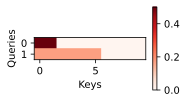

In [49]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                    xlabel='Keys', ylabel='Queries')

### 缩放点积注意力

使用点积可以得到计算效率更高的评分函数，但是点积操作要求查询和键具有相同的长度 $d$。假设查询和键的所有元素都是独立的随机变量，并且都满足零均值和单位方差，那么两个向量的点积的均值为 $0$，方差为 $d$。为确保无论向量长度如何，点积的方差在不考虑向量长度的情况下仍然是 $1$，我们再将点积除以 $\sqrt{d}$，则缩放点积注意力（scaled dot-product attention）评分函数为：

$$
a(\mathbf{q}, \mathbf{k}) = \mathbf{q}^\top \mathbf{k} / \sqrt{d}.
$$

在实践中，我们通常从小批量的角度来考虑提高效率，例如基于 $n$ 个查询和 $m$ 个键－值对计算注意力，其中查询和键的长度为 $d$，值的长度为 $v$。查询 $\mathbf{Q} \in \mathbb{R}^{n \times d}$、键 $\mathbf{K} \in \mathbb{R}^{m \times d}$ 和值 $\mathbf{V} \in \mathbb{R}^{m \times v}$ 的缩放点积注意力是：

$$
\mathrm{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d}}\right) \mathbf{V} \in \mathbb{R}^{n \times v}.
$$

In [50]:
#@save
class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
    
    # queries的形状：(batch_size, 查询的个数, d)
    # keys的形状：(batch_size, “键-值”对的个数, d)
    # values的形状：(batch_size, “键-值”对的个数, 值的维度)
    # valid_lens的形状：(batch_size, )或者(batch_size, 查询的个数)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # 设置transpose_b=True为了交换keys的最后两个维度
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [51]:
queries = torch.normal(0, 1, (2, 1, 2))
attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]])

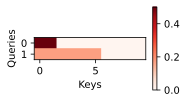

In [52]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                    xlabel='Keys', ylabel='Queries')

## Bahdanau注意力

### 模型

为了在每个解码时间步中可以重新考虑输入序列的一部分，Bahdanau 等人将一个非参数的注意力汇聚层加入到了 9.7 节中的循环神经网络编码器－解码器中。为了构造这个注意力汇聚层，我们使用了加性注意力评分函数。下面将介绍如何使用注意力机制实现循环神经网络编码器－解码器，并沿用 9.7 节中的符号约定。

假设输入序列中有 $T$ 个词元，在解码的第 $t'$ 个时间步，注意力汇聚的输出 $\mathbf{c}_{t'}$ 是：

$$
\mathbf{c}_{t'} = \sum_{t=1}^{T} \alpha(\mathbf{s}_{t'-1}, \mathbf{h}_t) \mathbf{h}_t.
$$

其中：

- 查询：解码器在时间步 $t'-1$ 的隐状态 $\mathbf{s}_{t'-1}$
- 键：编码器在各时间步的隐状态 $\mathbf{h}_t$
- 值：同样是编码器隐状态 $\mathbf{h}_t$

注意力权重 $\alpha$ 使用加性注意力评分函数计算。图描述了 Bahdanau 注意力架构，它与图 9.7.2 中的循环神经网络编码器－解码器架构略有不同。

<div align="center">
    <img src="../img/带Bahdanau注意力的循环神经网络编码器-解码器模型.png">
<div>

In [53]:
import torch
from torch import nn
from d2l import torch as d2l

### 定义注意力解码器

为了更⽅便地显⽰学习的注意⼒权重，以下AttentionDecoder类定义了带有注意⼒机制解码器的基本接⼝。

In [54]:
#@save
class AttentionDecoder(d2l.Decoder):
    """带有注意力机制解码器的基本接口"""
    def __init__(self, **kwargs):
        super(AttentionDecoder, self).__init__(**kwargs)

    @property
    def attention_weights(self):
        raise NotImplementedError

接下来，让我们在接下来的Seq2SeqAttentionDecoder类中实现带有Bahdanau注意⼒的循环神经⽹络解码器。
⾸先，初始化解码器的状态，需要下⾯的输⼊：
1. 编码器在所有时间步的最终层隐状态，将作为注意⼒的键和值；
2. 上⼀时间步的编码器全层隐状态，将作为初始化解码器的隐状态；
3. 编码器有效⻓度（排除在注意⼒池中填充词元）。

在每个解码时间步骤中，解码器上⼀个时间步的最终层隐状态将⽤作查询。因此，注意⼒输出和输⼊嵌⼊都连结为循环神经⽹络解码器的输⼊。

In [55]:
class Seq2SeqAttentionDecoder(AttentionDecoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                    dropout=0, **kwargs):
        super(Seq2SeqAttentionDecoder, self).__init__(**kwargs)
        self.attention = AdditiveAttention(
            num_hiddens, num_hiddens, num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(
            embed_size + num_hiddens, num_hiddens, num_layers,
            dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)
    
    def init_state(self, enc_outputs, enc_valid_lens, *args):
        # outputs的形状为(batch_size, num_steps, num_hiddens)
        # hidden_state的形状为(num_layers, batch_size, num_hiddens)
        outputs, hidden_state = enc_outputs
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        # enc_outputs的形状为(batch_size, num_steps, num_hiddens)
        # hidden_state的形状为(num_layers, batch_size, num_hiddens)
        enc_outputs, hidden_state, enc_valid_lens = state
        # 输出X的形状为(num_steps, batch_size, embed_size)
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            # query的形状为(batch_size, 1, num_hiddens)
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            # context的形状为(batch_size, 1, num_hiddens)
            context = self.attention(query, enc_outputs, enc_outputs, enc_valid_lens)
            # 在特征维度上链接
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            # 将x变形为(1, batch_size, embed_size+num_hiddens)
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        # 全连接层变换后，outputs的形状为(num_steps, batch_size, vocab_size)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state, enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights

In [56]:
encoder = d2l.Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16,
                                num_layers=2)
encoder.eval()
decoder = Seq2SeqAttentionDecoder(vocab_size=10, embed_size=8, num_hiddens=16,
                                    num_layers=2)
decoder.eval()
X = torch.zeros((4, 7), dtype=torch.long) # (batch_size, num_steps)
state = decoder.init_state(encoder(X), None)
output, state = decoder(X, state)
output.shape, len(state), state[0].shape, len(state[1]), state[1][0].shape                                

(torch.Size([4, 7, 10]), 3, torch.Size([4, 7, 16]), 2, torch.Size([4, 16]))

In [57]:
#@save 这里是第9章定义的
class EncoderDecoder(nn.Module):
    """编码器-解码器架构的基类"""
    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state)

### 训练

loss 0.021, 4852.8 tokens/sec on cuda:0


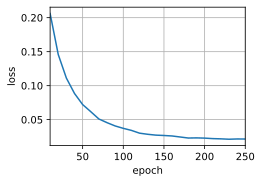

In [58]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 250, d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)
encoder = d2l.Seq2SeqEncoder(
    len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqAttentionDecoder(
    len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
net = EncoderDecoder(encoder, decoder)
d2l.train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [59]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, ',
        f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est mouillé .,  bleu 0.658
i'm home . => je suis chez moi .,  bleu 1.000


In [60]:
attention_weights = torch.cat([step[0][0][0] for step in dec_attention_weight_seq], 0).reshape((
1, 1,-1, num_steps))

训练结束后，下⾯通过可视化注意⼒权重会发现，每个查询都会在键值对上分配不同的权重，这说明在每个
解码步中，输⼊序列的不同部分被选择性地聚集在注意⼒池中。

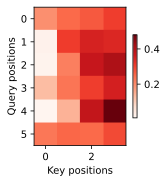

In [61]:
# 加上⼀个包含序列结束词元
d2l.show_heatmaps(
    attention_weights[:, :, :, :len(engs[-1].split()) + 1].cpu(),
    xlabel='Key positions', ylabel='Query positions')

## 多头注意力

与其只使⽤单独⼀个注意⼒汇聚，我们可以⽤独⽴学习得到的组不同的线性投影（linearprojections）来变换查询、键和值。然后，这组变换后的查询、键和值将并⾏地送到注意⼒汇聚中。最后，将这个注意⼒汇聚的输出拼接在⼀起，并且通过另⼀个可以学习的线性投影进⾏变换，以产⽣最终输出。这种设计被称为多头注意⼒（multiheadattention）。对于个注意⼒汇聚输出，每⼀个注意⼒汇聚都被称作⼀个头（head）。

<div align="center">
    <img src="../img/线性变换的多头注意力.png">
<div>

在实现多头注意力之前，让我们用数学语言来描述这个模型。给定查询 $\mathbf{q} \in \mathbb{R}^{d_q}$、键 $\mathbf{k} \in \mathbb{R}^{d_k}$ 和值 $\mathbf{v} \in \mathbb{R}^{d_v}$，每个注意力头 $\mathbf{h}_i$（$i = 1, \ldots, h$）的计算方法为：

$$
\mathbf{h}_i = f(\mathbf{W}_i^{(q)}\mathbf{q}, \mathbf{W}_i^{(k)}\mathbf{k}, \mathbf{W}_i^{(v)}\mathbf{v}) \in \mathbb{R}^{p_v},
$$

其中可学习参数为 $\mathbf{W}_i^{(q)} \in \mathbb{R}^{p_q \times d_q}$、$\mathbf{W}_i^{(k)} \in \mathbb{R}^{p_k \times d_k}$ 和 $\mathbf{W}_i^{(v)} \in \mathbb{R}^{p_v \times d_v}$，并且可代表式注意力汇聚。$f$ 可以是 10.3 节中的加性注意力和缩放点积注意力。多头注意力的输出需要经过另一个线性变换，它对应于 $h$ 个头连结后的结果，因此其可学习参数是 $\mathbf{W}_o \in \mathbb{R}^{p_o \times h p_v}$：

$$
\mathbf{W}_o \begin{bmatrix} \mathbf{h}_1 \\ \vdots \\ \mathbf{h}_h \end{bmatrix} \in \mathbb{R}^{p_o}.
$$

基于这种设计，每个头都可能会关注输入的不同部分，可以表示比简单加权平均值更复杂的函数。

In [62]:
import math
import torch
from torch import nn
from d2l import torch as d2l

### 实现

在实现过程中通常选择缩放点积注意力作为每一个注意力头。为了避免计算代价和参数代价的大幅增长，我们设定 $p_q = p_k = p_v = p_o / h$。值得注意的是，如果将查询、键和值的线性变换的输出数量设置为 $p_q h = p_k h = p_v h = p_o$，则可以并行计算 $h$ 个头。在下面的实现中，$p_o$ 是通过参数 `num_hiddens` 指定的。

为了能够使多个头并⾏计算，上⾯的MultiHeadAttention类将使⽤下⾯定义的两个转置函数。具体来说，transpose_output函数反转了transpose_qkv函数的操作。

In [63]:
#@save
def transpose_qkv(X, num_heads):
    """为了多注意力头的并行计算而变换形状"""
    # 输入X的形状：(batch_size, 查询或者“键-值”对的个数, num_hiddens)
    # 输出X的形状：(batch_size, 查询或者“键-值”对的个数, num_heads, num_hiddens / num_heads)
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)

    # 输出X的形状：(batch_size, num_heads, 查询或者“键-值”对的个数, num_hiddens / num_heads)
    X = X.permute(0, 2, 1, 3)

    # 最终输出的形状：(batch_size * num_heads, 查询或者“键-值”对的个数, num_hiddens / num_heads)
    return X.reshape(-1, X.shape[2], X.shape[3])

#@save
def transpose_output(X, num_heads):
    """逆转transpose_qkv函数的操作"""
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

In [64]:
#@save
class MultiHeadAttention(nn.Module):
    """多头注意力"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                    num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention=d2l.DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # queries, keys, values的形状：
        # (batch_size, 查询或着“键-值”对的个数, num_hiddens)
        # valid_lens的形状(batch_size, )或(batch_size, 查询的个数)
        # 经过变换后，输出的queries, keys, values的形状：
        # (batch_size * num_heads, 查询或者“键-值”对的个数, num_hiddens / num_heads)
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)
        
        if valid_lens is not None:
            # 在轴0，将第一项(标量或矢量)复制num_heads次，
            # 然后如此复制第二项，然后诸如此类
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)
        
        # output的形状：(batch_size * num_heads, 查询的个数, num_hiddens / num_heads)
        output = self.attention(queries, keys, values, valid_lens)

        # output_concat的形状：(batch_size, 查询的个数, num_hiddens)
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

下⾯使⽤键和值相同的⼩例⼦来测试我们编写的MultiHeadAttention类。多头注意⼒输出的形状是（batch_size，num_queries，num_hiddens）。

In [65]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_hiddens, 
                                num_hiddens, num_hiddens, num_heads, 0.5)
attention.eval()

MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): Linear(in_features=100, out_features=100, bias=False)
  (W_k): Linear(in_features=100, out_features=100, bias=False)
  (W_v): Linear(in_features=100, out_features=100, bias=False)
  (W_o): Linear(in_features=100, out_features=100, bias=False)
)

In [66]:
batch_size, num_queries = 2, 4
num_kvpairs, valid_lens = 6, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
attention(X, Y, Y, valid_lens).shape

torch.Size([2, 4, 100])

### 练习

假设有一个完成训练的基于多头注意力的模型，现在希望修剪最不重要的注意力头以提高预测速度。如何设计实验来度量注意力头的重要性呢？


要度量注意力头的重要性，可以使用以下方法：

可以使用类似于Dropout的技术，随机地将某些注意力头从模型中删除，然后比较删除前后模型的性能差异。
优点：简单易行
缺点：可能会导致模型过拟合
可以使用Taylor Expansion来计算每个注意力头对于模型输出的贡献度。
优点：可以更准确地度量每个注意力头的重要性
缺点：计算量大
可以使用Attention Flow来计算每个注意力头对于每个输入位置的重要性。
优点：可以更好地理解模型在处理输入序列时的行为。
缺点：计算量大，需要更多的内存来存储注意力权重。

## 自注意力和位置编码

具体来说，每个查询都会关注所有的键－值对并⽣成⼀个注意⼒输出。由于查询、键和值来⾃同⼀组输⼊，因此被称为⾃注意⼒（self-attention）。

In [67]:
import math
import torch
from torch import nn
from d2l import torch as d2l

### 自注意力

In [68]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens,
                                num_hiddens, num_heads, 0.5)
attention.eval()

MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): Linear(in_features=100, out_features=100, bias=False)
  (W_k): Linear(in_features=100, out_features=100, bias=False)
  (W_v): Linear(in_features=100, out_features=100, bias=False)
  (W_o): Linear(in_features=100, out_features=100, bias=False)
)

In [69]:
batch_size, num_queries, valid_lens = 2, 4, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
attention(X, X, X, valid_lens).shape

torch.Size([2, 4, 100])

### 比较卷积神经网络、循环神经网络和自注意力

接下来比较下面几个架构，目标都是将由 $n$ 个词元组成的序列映射到另一个长度相等的序列，其中的每个输入词元或输出词元都由 $d$ 维向量表示。具体来说，将比较的是卷积神经网络、循环神经网络和自注意力这几个架构的**计算复杂性**、**顺序操作**和**最大路径长度**。

请注意：

- 顺序操作会妨碍并行计算；
- 任意序列位置组合之间的路径越短，则越容易学习序列中的远距离依赖关系（Hochreiter *et al.*, 2001）。

<div align="center">
    <img src="../img/⽐较卷积神经⽹络、循环神经⽹络和⾃注意⼒三种架构.png">
<div>

考虑一个卷积核大小为 $k$ 的卷积层。在后面的章节将提供关于使用卷积神经网络处理序列的更多详细信息。目前只需要知道的是，由于序列长度是 $n$，输入和输出的通道数量都是 $d$，所以卷积层的计算复杂度为 $\mathcal{O}(knd^2)$。如图 10.6.1 所示，卷积神经网络是分层的，因此为有 $\mathcal{O}(1)$ 个顺序操作，最大路径长度为 $\mathcal{O}(n/k)$。例如，$\mathbf{x}_1$ 和 $\mathbf{x}_5$ 处于图 10.6.1 中卷积核大小为 3 的双层卷积神经网络的感受野内。

当更新循环神经网络的隐状态时，$d \times d$ 权重矩阵和 $d$ 维隐状态的乘法计算复杂度为 $\mathcal{O}(d^2)$。由于序列长度为 $n$，因此循环神经网络层的计算复杂度为 $\mathcal{O}(nd^2)$。根据图 10.6.1，有 $\mathcal{O}(n)$ 个顺序操作无法并行化，最大路径长度也是 $\mathcal{O}(n)$。

在自注意力中，查询、键和值都是 $n \times d$ 矩阵。考虑 (10.3.5) 中缩放的点积注意力，其中 $n \times d$ 矩阵乘以 $d \times n$ 矩阵，之后输出的 $n \times n$ 矩阵再乘以 $n \times d$ 矩阵。因此，自注意力具有 $\mathcal{O}(n^2 d)$ 计算复杂度。正如在图 10.6.1 中所讲，每个词元都通过自注意力直接连接到任何其他词元。因此，有 $\mathcal{O}(1)$ 个顺序操作可以并行计算，最大路径长度也是 $\mathcal{O}(1)$。

总而言之，卷积神经网络和自注意力都拥有并行计算的优势，而且自注意力的最大路径长度最短。但是因为其计算复杂度是关于序列长度的二次方，所以在很长的序列中计算会非常慢。

**一句话对比：** CNN 可并行但路径偏长；RNN 便宜但难并行、路径最长；自注意力路径最短且可并行，但代价是 $\mathcal{O}(n^2)$，长序列会慢。

### 位置编码

与循环神经网络不同，自注意力因为并行计算而放弃了顺序操作。为了使用序列的顺序信息，通过在输入表示中添加位置编码（positional encoding）来注入绝对或相对位置信息。位置编码可以是可学习的，也可以是固定的。接下来描述的是基于正弦函数和余弦函数的固定位置编码（Vaswani et al., 2017）。

假设输入表示 $\mathbf{X} \in \mathbb{R}^{n \times d}$ 包含一个序列中 $n$ 个词元的 $d$ 维嵌入向量。位置编码使用相同形状的位置嵌入矩阵 $\mathbf{P} \in \mathbb{R}^{n \times d}$ 输出 $\mathbf{X} + \mathbf{P}$，矩阵第 $i$ 行、第 $2j$ 列和 $2j+1$ 列上的元素为：

$$
\begin{aligned}
p_{i, 2j} &= \sin\left(\frac{i}{10000^{2j/d}}\right), \\
p_{i, 2j+1} &= \cos\left(\frac{i}{10000^{2j/d}}\right).
\end{aligned}
$$

乍一看，这种基于三角函数的设计看起来很奇怪。在下面的 `PositionalEncoding` 类中，我们将这种位置嵌入矩阵的实现。

In [70]:
class PositionalEncoding(nn.Module):
    """位置编码"""
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        # 创建一个足够长的P
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(-1, 1
            ) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)
    
    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

在位置嵌⼊矩阵P中，⾏代表词元在序列中的位置，列代表位置编码的不同维度。从下⾯的例⼦中可以看到位置嵌⼊矩阵的第6列和第7列的频率⾼于第8列和第9列。第6列和第7列之间的偏移量（第8列和第9列相同）是由于正弦函数和余弦函数的交替。

    行（整行向量）让模型能够区分不同的绝对位置（即感知'这是第几个词'）；列（不同频率的波形）则通过构造可线性变换的几何空间，让模型能够轻松捕获词元之间的相对距离（即感知'你离我有多远'）。

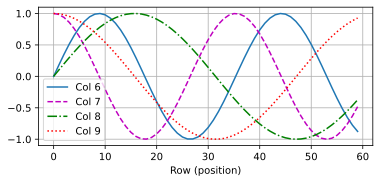

In [71]:
encoding_dim, num_steps = 32, 60
pos_encoding = PositionalEncoding(encoding_dim, 0)
pos_encoding.eval()
X = pos_encoding(torch.zeros((1, num_steps, encoding_dim)))
P = pos_encoding.P[:, :X.shape[1], :]
d2l.plot(torch.arange(num_steps), P[0, :, 6:10].T, xlabel='Row (position)',
            figsize=(6, 2.5), legend=["Col %d" % d for d in torch.arange(6, 10)])

#### 绝对位置信息

为了明⽩沿着编码维度单调降低的频率与绝对位置信息的关系，让我们打印出0,1,...,7的⼆进制表⽰形式。正如所看到的，每个数字、每两个数字和每四个数字上的⽐特值在第⼀个最低位、第⼆个最低位和第三个最低位上分别交替。

In [72]:
for i in range(8):
    print(f'{i}的二进制是：{i:>03b}')

0的二进制是：000
1的二进制是：001
2的二进制是：010
3的二进制是：011
4的二进制是：100
5的二进制是：101
6的二进制是：110
7的二进制是：111


在⼆进制表⽰中，较⾼⽐特位的交替频率低于较低⽐特位，与下⾯的热图所⽰相似，只是位置编码通过使⽤三⻆函数在编码维度上降低频率。由于输出是浮点数，因此此类连续表⽰⽐⼆进制表⽰法更节省空间。

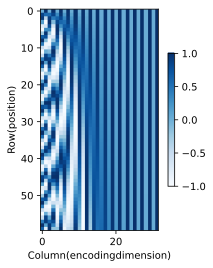

In [73]:
P= P[0,:,:].unsqueeze(0).unsqueeze(0)
d2l.show_heatmaps(P,xlabel='Column(encodingdimension)',
                    ylabel='Row(position)',figsize=(3.5, 4),cmap='Blues')

#### 相对位置信息

除了捕获绝对位置信息之外，上述的位置编码还允许模型学习得到输入序列中相对位置信息。这是因为对于任何确定的位置偏移 $\delta$，位置 $i + \delta$ 处的位置编码可以线性投影位置 $i$ 处的位置编码来表示。

这种投影的数学解释是，令 $\omega_j = 1/10000^{2j/d}$，对于任何确定的位置偏移 $\delta$，(10.6.2) 中的任何一对 $(p_{i, 2j}, p_{i, 2j+1})$ 都可以线性投影到 $(p_{i+\delta, 2j}, p_{i+\delta, 2j+1})$：

$$
\begin{aligned}
\begin{bmatrix}
\cos(\delta \omega_j) & \sin(\delta \omega_j) \\
-\sin(\delta \omega_j) & \cos(\delta \omega_j)
\end{bmatrix}
\begin{bmatrix}
p_{i, 2j} \\
p_{i, 2j+1}
\end{bmatrix}
&=
\begin{bmatrix}
\cos(\delta \omega_j)\sin(i\omega_j) + \sin(\delta \omega_j)\cos(i\omega_j) \\
-\sin(\delta \omega_j)\sin(i\omega_j) + \cos(\delta \omega_j)\cos(i\omega_j)
\end{bmatrix} \\
&=
\begin{bmatrix}
\sin((i+\delta)\omega_j) \\
\cos((i+\delta)\omega_j)
\end{bmatrix}

=

\begin{bmatrix}
p_{i+\delta, 2j} \\
p_{i+\delta, 2j+1}
\end{bmatrix}.

\end{aligned}
$$

$2 \times 2$ 投影矩阵不依赖于任何位置的索引 $i$。

**小结：** 正弦/余弦位置编码不但标绝对位置，还让相对偏移 $\delta$ 对应一个与 $i$ 无关的线性变换，方便模型学相对位置。

## Transformer

图10.7.1中概述了**Transformer**的架构。从宏观角度来看，**Transformer**的**编码器**是由多个相同的层叠加而成的，每个层都有两个子层（子层表示为**sublayer**）。第一个子层是**多头自注意力（multi-head self-attention）**汇聚；第二个子层是**基于位置的前馈网络（positionwise feed-forward network）**。具体来说，在计算编码器的自注意力时，查询、键和值都来自前一个编码器层的输出。受7.6节中残差网络的启发，每个子层都采用了**残差连接（residual connection）**。在**Transformer**中，对于序列中任何位置的任何输入$\mathbf{x} \in \mathbb{R}^d$，都要求满足$sublayer(\mathbf{x}) \in \mathbb{R}^d$，以便残差连接满足$\mathbf{x} + sublayer(\mathbf{x}) \in \mathbb{R}^d$。在残差连接的加法计算之后，紧接着应用**层规范化（layer normalization）**(Ba *et al.*, 2016)。因此，输入序列对应的每个位置，**Transformer**编码器都将输出一个$d$维表示向量。

Transformer解码器也是由多个相同的层叠加而成的，并且层中使用了残差连接和层规范化。除了编码器中描述的两个子层之外，解码器还在这两个子层之间插入了第三个子层，称为编码器－解码器注意力（encoder-decoder attention）层。在编码器－解码器注意力中，查询来自前一个解码器层的输出，而键和值来自整个编码器的输出。在解码器自注意力中，查询、键和值都来自上一个解码器层的输出。但是，解码器中的每个位置只能考虑该位置之前的所有位置。这种掩蔽（masked）注意力保留了自回归（auto-regressive）属性，确保预测仅依赖于已生成的输出词元。

<div align="center">
    <img src="../img/transformer架构.png">
<div>

In [74]:
import math
import torch
import pandas as pd
from torch import nn
from d2l import torch as d2l

### 基于位置的前馈网络

基于位置的前馈⽹络对序列中的所有位置的表⽰进⾏变换时使⽤的是同⼀个多层感知机（MLP），这就是称前馈⽹络是基于位置的（positionwise）的原因。在下⾯的实现中，输⼊X的形状（批量⼤⼩，时间步数或序列⻓度，隐单元数或特征维度）将被⼀个两层的感知机转换成形状为（批量⼤⼩，时间步数，ffn_num_outputs）的输出张量。

In [75]:
#@save
class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                    **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

下⾯的例⼦显⽰，改变张量的最⾥层维度的尺⼨，会改变成基于位置的前馈⽹络的输出尺⼨。因为⽤同⼀个多层感知机对所有位置上的输⼊进⾏变换，所以当所有这些位置的输⼊相同时，它们的输出也是相同的。

In [76]:
ffn = PositionWiseFFN(4, 4, 8)
ffn.eval()
ffn(torch.ones((2, 3, 4)))[0]

tensor([[ 0.2579, -0.5188,  0.6881, -0.1247,  0.2087, -0.0512, -0.2477, -0.1591],
        [ 0.2579, -0.5188,  0.6881, -0.1247,  0.2087, -0.0512, -0.2477, -0.1591],
        [ 0.2579, -0.5188,  0.6881, -0.1247,  0.2087, -0.0512, -0.2477, -0.1591]],
       grad_fn=<SelectBackward0>)

### 残差链接和层规范化

正如在本节开头所述，这是由残差连接和紧随其后的层规范化组成的。**两者都是构建有效的深度架构的关键**。

7.5节中解释了在⼀个⼩批量的样本内基于批量规范化对数据进⾏重新中⼼化和重新缩放的调整。层规范化和批量规范化的⽬标相同，但层规范化是基于特征维度进⾏规范化。尽管批量规范化在计算机视觉中被⼴泛应⽤，但在⾃然语⾔处理任务中（输⼊通常是变⻓序列）批量规范化通常不如层规范化的效果好。

> 假设输入数据的形状为 [batch_size, seq_len, d_model]（即 [批次大小, 序列长度, 特征维度]）。

> 批量规范化（Batch Norm）：沿着 “批次” 和 “序列长度” 方向求均值和方差。也就是说，它会把同一个批次中、所有位置上的所有样本的同一个特征维度（比如第256个特征）拿出来做归一化。它依赖“批次”中的其他样本。

> 层规范化（Layer Norm）：沿着 “特征维度”（即 d_model）方向求均值和方差。也就是说，它会把当前这一个样本、当前这一个位置上的所有特征值（总共d_model个）拿出来做归一化。它完全不依赖批次中的其他样本，只看自己。

In [77]:
ln = nn.LayerNorm(2)
bn = nn.BatchNorm1d(2)
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)
# 在训练模式下计算X的均值和方差
print('layer norm:', ln(X), '\nbatch norm:', bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [78]:
#@save
class AddNorm(nn.Module):
    """残差连接后进行层规范化"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

残差连接要求两个输⼊的形状相同，以便加法操作后输出张量的形状相同。

In [79]:
add_norm = AddNorm([3, 4], 0.5)
add_norm.eval()
add_norm(torch.ones((2, 3, 4)), torch.ones((2, 3, 4))).shape

torch.Size([2, 3, 4])

### 编码器

有了组成Transformer编码器的基础组件，现在可以先实现编码器中的⼀个层。下⾯的EncoderBlock类包含两个⼦层：多头⾃注意⼒和基于位置的前馈⽹络，这两个⼦层都使⽤了残差连接和紧随的层规范化。

In [80]:
class EncoderBlock(nn.Module):
    """Transformer编码器块"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                    dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads,
            dropout, use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(
            ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

正如从代码中所看到的，Transformer编码器中的任何层都不会改变其输⼊的形状。

In [81]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = EncoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5)
encoder_blk.eval()
encoder_blk(X, valid_lens).shape

torch.Size([2, 100, 24])

下⾯实现的Transformer编码器的代码中，堆叠了num_layers个EncoderBlock类的实例。由于这⾥使⽤的是值范围在-1和1之间的固定位置编码，因此通过学习得到的输⼊的嵌⼊表⽰的值需要先乘以嵌⼊维度的平⽅根进⾏重新缩放，然后再与位置编码相加。

> 由于嵌入向量的每个维度值通常很小，这个缩放操作本质上是为了平衡“语义信息”（嵌入）和“位置信息”（编码）在数值上的贡献。

In [82]:
#@save
class TransformerEncoder(d2l.Encoder):
    """Transformer编码器"""
    def __init__(self, vocab_size, key_size, query_size, value_size,
                    num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                    num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                EncoderBlock(key_size, query_size, value_size, num_hiddens,
                                norm_shape, ffn_num_input, ffn_num_hiddens,
                                num_heads, dropout, use_bias))
    
    def forward(self, X, valid_lens, *args):
        # 因为位置编码值在-1和1之间，
        # 因此嵌入值乘以嵌入维度的平方根进行缩放，
        # 然后再与位置编码相加。
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[
                i] = blk.attention.attention.attention_weights
        return X

In [83]:
encoder = TransformerEncoder(
    200, 24, 24, 24, 24, [100, 24], 24, 48, 8, 2, 0.5)
encoder.eval()
encoder(torch.ones((2, 100), dtype=torch.long), valid_lens).shape

torch.Size([2, 100, 24])

### 解码器

正如在本节前面所述，在掩蔽多头解码器自注意力层（第一个子层）中，查询、键和值都来自上一个解码器层的输出。关于序列到序列模型（sequence-to-sequence model），在训练阶段，其输出序列的所有位置（时间步）的词元都是已知的；然而，在预测阶段，其输出序列的词元是逐个生成的。因此，在任何解码器时间步中，只有生成的词元才能用于解码器的自注意力计算中。为了在解码器中保留自回归的属性，其掩蔽自注意力设定了参数`dec_valid_lens`，以便任何查询都只会与解码器中所有已经生成词元的位置（即直到该查询位置为止）进行注意力计算。

In [84]:
class DecoderBlock(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                    dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i
        self.attention1 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # 训练阶段，输出序列的所有词元都在同一时间处理，
        # 因此state[2][self.i]初始化为None。
        # 预测阶段，输出序列是通过词元一个接着一个解码的，
        # 因此state[2][self.i]包含着知道当前时间步第i个块解码的输出表示
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape
            # dec_valid_lens的开头：(batch_size, num_steps)，
            # 其中每一行是[1, 2, ..., num_steps]
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None
        
        # 自注意力
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        # 编码器-解码器注意力。
        # enc_outputs的开头：(batch_size, num_steps, num_hiddens)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

In [85]:
decoder_blk = DecoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5, 0)
decoder_blk.eval()
X = torch.ones((2, 100, 24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
decoder_blk(X, state)[0].shape

torch.Size([2, 100, 24])

现在我们构建了由num_layers个DecoderBlock实例组成的完整的Transformer解码器。最后，通过⼀个全连接层计算所有vocab_size个可能的输出词元的预测值。解码器的⾃注意⼒权重和编码器解码器注意⼒权重都被存储下来，⽅便⽇后可视化的需要。

In [86]:
class TransformerDecoder(AttentionDecoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,
                    num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                    num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                    DecoderBlock(key_size, query_size, value_size, num_hiddens,
                                    norm_shape, ffn_num_input, ffn_num_hiddens,
                                    num_heads, dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size)
    
    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range(2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # 解码器自注意力权重
            self._attention_weights[0][
                i] = blk.attention1.attention.attention_weights
            # “编码器-解码器”自注意力权重
            self._attention_weights[1][
                i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

### 训练

依照Transformer架构来实例化编码器－解码器模型。在这⾥，指定Transformer的编码器和解码器都是2层，都使⽤4头注意⼒。与9.7.4节类似，为了进⾏序列到序列的学习，下⾯在“英语－法语”机器翻译数据集上训练Transformer模型。

loss 0.031, 6341.4 tokens/sec on cuda:0


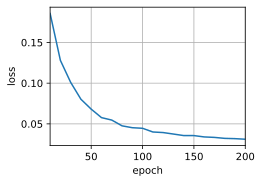

In [88]:
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 10
lr, num_epochs, device = 0.005, 200, d2l.try_gpu()
ffn_num_input, ffn_num_hiddens, num_heads = 32, 64, 4
key_size, query_size, value_size = 32, 32, 32
norm_shape = [32]
train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

encoder = TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
decoder = TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
net = EncoderDecoder(encoder, decoder)
d2l.train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

训练结束后，使⽤Transformer模型将⼀些英语句⼦翻译成法语，并且计算它们的BLEU分数。

In [89]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, ',
        f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est paresseux .,  bleu 0.658
i'm home . => je suis chez moi .,  bleu 1.000


当进⾏最后⼀个英语到法语的句⼦翻译⼯作时，让我们可视化Transformer的注意⼒权重。编码器⾃注意⼒权重的形状为（编码器层数，注意⼒头数，num_steps或查询的数⽬，num_steps或“键－值”对的数⽬）。

In [90]:
enc_attention_weights = torch.cat(net.encoder.attention_weights, 0).reshape((num_layers, num_heads,
                                -1, num_steps))
enc_attention_weights.shape

torch.Size([2, 4, 10, 10])

在编码器的⾃注意⼒中，查询和键都来⾃相同的输⼊序列。因为填充词元是不携带信息的，因此通过指定输⼊序列的有效⻓度可以避免查询与使⽤填充词元的位置计算注意⼒。接下来，将逐⾏呈现两层多头注意⼒的权重。每个注意⼒头都根据查询、键和值的不同的表⽰⼦空间来表⽰不同的注意⼒。

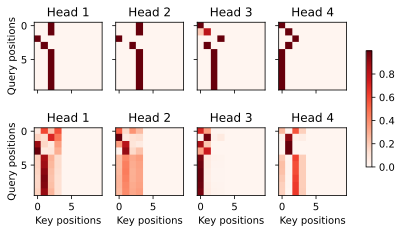

In [91]:
d2l.show_heatmaps(
    enc_attention_weights.cpu(), xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))

为了可视化解码器的⾃注意⼒权重和“编码器－解码器”的注意⼒权重，我们需要完成更多的数据操作⼯作。例如⽤零填充被掩蔽住的注意⼒权重。值得注意的是，解码器的⾃注意⼒权重和“编码器－解码器”的注意⼒权重都有相同的查询：即以序列开始词元（beginning-of-sequence,BOS）打头，再与后续输出的词元共同组成序列。

In [92]:
dec_attention_weights_2d = [head[0].tolist()
                            for step in dec_attention_weight_seq
                            for attn in step for blk in attn for head in blk]
dec_attention_weights_filled = torch.tensor(
    pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)
dec_attention_weights = dec_attention_weights_filled.reshape((-1, 2, num_layers, num_heads, num_steps))
dec_self_attention_weights, dec_inter_attention_weights = \
    dec_attention_weights.permute(1, 2, 3, 0, 4)
dec_self_attention_weights.shape, dec_inter_attention_weights.shape

(torch.Size([2, 4, 6, 10]), torch.Size([2, 4, 6, 10]))

由于解码器⾃注意⼒的⾃回归属性，查询不会对当前位置之后的“键－值”对进⾏注意⼒计算。

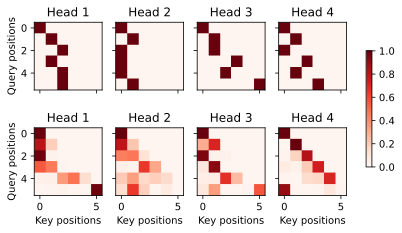

In [93]:
# Plusonetoincludethebeginning-of-sequencetoken
d2l.show_heatmaps(
    dec_self_attention_weights[:, :, :, :len(translation.split()) + 1],
    xlabel='Key positions', ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)], figsize=(7, 3.5))

与编码器的⾃注意⼒的情况类似，通过指定输⼊序列的有效⻓度，输出序列的查询不会与输⼊序列中填充位置的词元进⾏注意⼒计算。

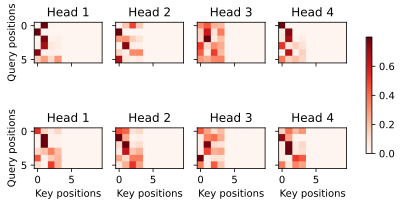

In [94]:
d2l.show_heatmaps(
    dec_inter_attention_weights, xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))

尽管Transformer架构是为了序列到序列的学习⽽提出的，但正如本书后⾯将提及的那样，Transformer编码器或Transformer解码器通常被单独⽤于不同的深度学习任务中。